In [1]:
import os
#from pathlib import Path
#import re
import pandas as pd
import numpy as np
from PIL import Image
from skimage.color import rgb2gray
from skimage.draw import disk
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import math

In [2]:
def filename(path):
    """
    Return filename without extenstion
    """
    return os.path.splitext(os.path.basename(path))[0]

def draw_foci_with_radius(image_path, df, px_size_nm, output_path, plot = True, save = True):
    # Load image
    image = Image.open(image_path)
    image_name = filename(image_path)
    arr = np.array(image) # convert image to numpy matrix

    # Plot image
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(arr, cmap="gray")

    # Draw red circles
    for _, row in df.iterrows():

        x_px = row["x_nm"] / px_size_nm
        y_px = row["y_nm"] / px_size_nm
        r_px = row["sigma_nm"] / px_size_nm

        circle = Circle(
            (x_px, y_px),
            r_px,
            fill=False,
            edgecolor="red",
            linewidth=1
        )

        ax.add_patch(circle)

    # Match image coordinates
    ax.set_xlim(0, arr.shape[1])
    ax.set_ylim(arr.shape[0], 0)

    # Show image
    if plot:
        plt.show(fig)

    # Save image
    if save: 
        plt.savefig(
            f"{output_path}/{image_name}_sigma.png",
            dpi=300,
            bbox_inches="tight"
        )

        # Do not display image
        plt.close(fig)

def foci_one_image(image_path, df, px_size_um, output_path, plot = True, save_image = True):
    image = Image.open(image_path)  # load image
    image_name = filename(image_path) # get image name
    arr = np.array(image) # convert image to numpy matrix
    H, W = arr.shape # get number of pixels (512*512 for 16-bit image)

    # Storage lists
    x_list = []
    y_list = []
    sigma_list = []
    mean_list = []

    # Iteration through the thunderSTORM dataframe
    for _, row in df.iterrows():
        x_px = int(row["x_um"] / px_size_um)
        y_px = int(row["y_um"] / px_size_um)
        r_px = max(1, int(row["sigma_um"] / px_size_um)) # minimal possible value for radius is 1 pixel!

        # Build circular mask (clipped automatically)
        rr, cc = disk((y_px, x_px), r_px, shape=(H, W))
        mask = np.zeros((H, W), dtype=bool)
        mask[rr, cc] = True

        n_pixels_mask = np.sum(mask)

        # Compute mean intensity
        if n_pixels_mask > 0:
            mean_intensity = arr[mask].mean()
        else:
            mean_intensity = np.nan
        #print(x_px, x_px, r_px, n_pixels_mask, mean_intensity)

        # Add values to the corresponding lists
        x_list.append(x_px)
        y_list.append(y_px)
        sigma_list.append(r_px)
        mean_list.append(mean_intensity)
    
    # Return modified copy
    df_out = df.copy()
    df_out["x_pixel"] = x_list
    df_out["y_pixel"] = y_list
    df_out["sigma_pixel"] = sigma_list
    df_out["foci_MFI"] = mean_list

    # Make a plot and save image
    if plot:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(arr, cmap="gray")

        for _, row in df_out.iterrows():
            x = row["x_pixel"]
            y = row["y_pixel"]
            r = row["sigma_pixel"]

            circle = Circle(
            (x, y),
            r,
            fill=False,
            edgecolor="red",
            linewidth=1
            )

            ax.add_patch(circle)
        
        # Match image coordinates
        ax.set_xlim(0, arr.shape[1])
        ax.set_ylim(arr.shape[0], 0)

        plt.show(fig)

        # Save imafe
        if save_image:
            plt.savefig(
                f"{output_path}/{image_name}_sigma.png",
                dpi=300,
                bbox_inches="tight"
            )

        # Do not display image
        plt.close(fig)

    return df_out

In [3]:
image_path = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314.tif"
px_size_nm = 58.739
output_path = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/foci"
image = Image.open(image_path) # open image
arr = np.array(image) # convert image to matrix
arr = np.array(image, dtype=np.float32) # convert values to float
H, W = arr.shape # get number of pixels (512*512 for 16-bit image)
#px_size_um = 0.058739

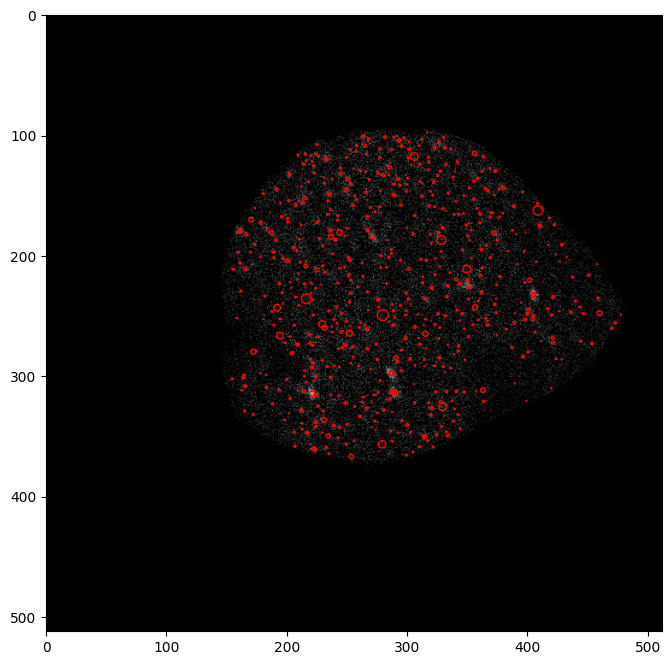

In [10]:
draw_foci_with_radius(image_path, dfs[0], px_size_nm, output_path, plot = True, save = False)

In [4]:
dir_images = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3"
dir_foci = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/foci"

In [6]:
paths_images = [
    os.path.join(dir_images, f)
    for f in os.listdir(dir_images)
    if os.path.isfile(os.path.join(dir_images, f))
    and f.lower().endswith(".tif") and "_ROI_".lower() in f.lower()
]

paths_foci_csv = [
    os.path.join(dir_foci, f)
    for f in os.listdir(dir_foci)
    if os.path.isfile(os.path.join(dir_foci, f))
    and f.lower().endswith(".csv")   
    ]

img_by_key = {filename(image_name): image_name for image_name in paths_images} # dictionary {image name w/o ext: image path}
csv_by_key = {filename(csv_name)[:-5]: csv_name for csv_name in paths_foci_csv} # dictionary {csv file name w/o ext: image path}
combined = {k: (img_by_key[k], csv_by_key[k]) for k in img_by_key} # dictionary {file_name: (path_to_image, path_to_foci_csv)}
#n_images = len(combined)

In [7]:
# Create list of dataframes
dfs = []

# Variables
px = 58.739
savepath = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/test"

# Iteration through all the files in the folder
for name, (img_path, csv_path) in combined.items():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()  # remove hidden spaces in headers
    df = df.rename(columns={"x [nm]": "x_nm", "y [nm]": "y_nm", "sigma [nm]": "sigma_nm", "intensity [photon]": "intensity_photon"}) # Rename columns
    dfs.append(df) # add df to the list of dataframes
    
    #draw_foci_with_radius(image_path = img_path, df = df, px_size_nm = px, output_path = savepath)
    #foci_one_image(image_path, df, px_size_um, output_path, plot = True)
    
    

In [8]:
combined['C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314']

('/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314.tif',
 '/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/foci/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314_foci.csv')

In [9]:
dfs[0]

,id,x_nm,y_nm,sigma_nm,intensity_photon
0,1.0,9098.278265,17753.074639,40.017841,16.523757
1,2.0,9136.999106,12401.308820,47.103523,42.692367
2,3.0,9428.050829,10551.778833,79.018673,110.932665
3,4.0,9476.263273,10502.598320,70.661461,121.836552
4,5.0,9380.491931,11574.509803,41.119091,16.520303
...,...,...,...,...,...
584,585.0,26941.070723,13801.702262,46.988179,23.797248
585,586.0,27011.685869,14549.041193,123.026256,0.821806
586,587.0,27623.056270,15282.662310,40.721554,28.094449
587,588.0,27788.812993,15022.673074,46.273279,29.746101
